# Statistical Relationships

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

## Timeseries Plots

In [3]:
dowjones = sns.load_dataset("dowjones")
dowjones.head()

,Date,Price
0,1914-12-01,55.00
1,1915-01-01,56.55
2,1915-02-01,56.00
3,1915-03-01,58.30
4,1915-04-01,66.45


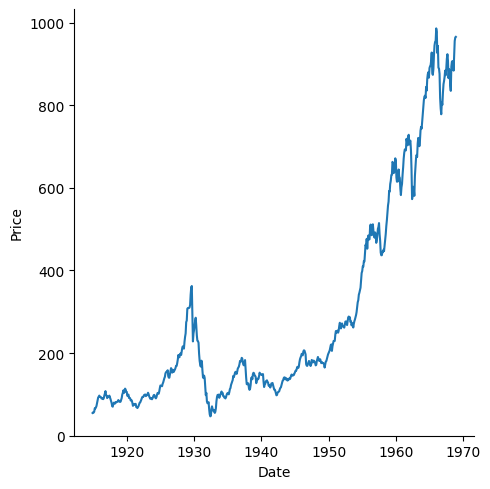

In [4]:
sns.relplot(
    data=dowjones, kind="line",
    x="Date", y="Price",
)

## Finding Correlation

In [5]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


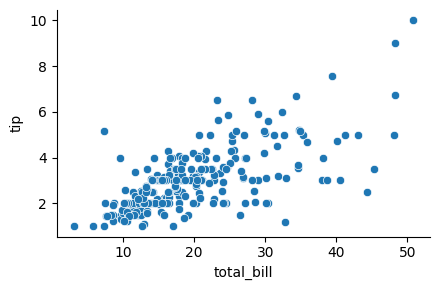

In [6]:
sns.relplot(
    data=tips,
    x="total_bill", y="tip",
    aspect=1.5, height=3
)

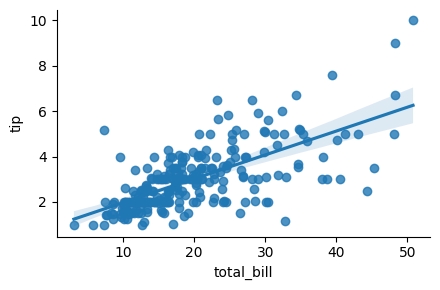

In [7]:
sns.lmplot(
    data=tips,
    x="total_bill", y="tip",
    aspect=1.5, height=3
)

- Question: **What is the shaded region around the line?**
- Answer: **Confidence Interval** (CI). The further away the line is from the dataset, the narrow the shaded region is, indicating less certainty.

While the points are plotted in two dimensions, **another dimension can be added** to the plot by coloring the points according to a third variable. In seaborn, this is referred to as using a “`hue` semantic”, because the color of the point gains meaning:

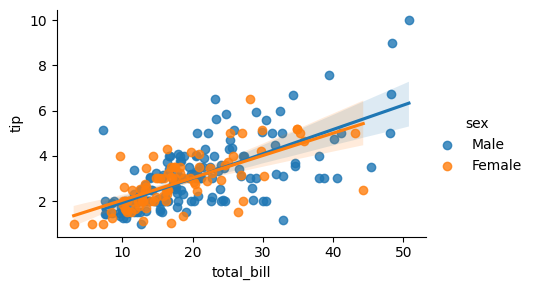

In [9]:
sns.lmplot(
    data=tips,
    x="total_bill", y="tip", hue="sex",
    aspect=1.5, height=3
)

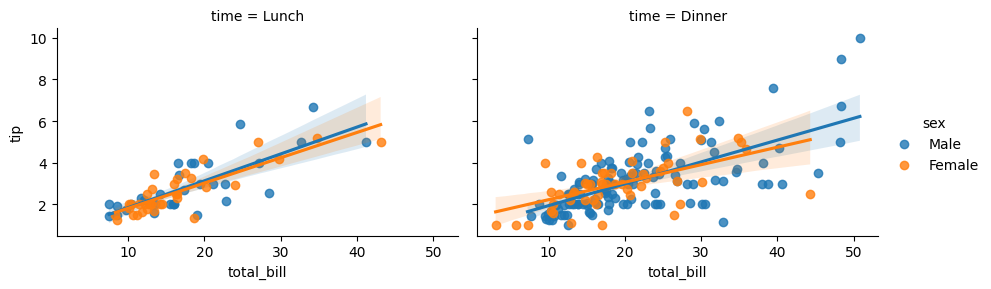

In [6]:
sns.lmplot(
    data=tips,
    x="total_bill", y="tip", hue="sex", col="time",
    aspect=1.5, height=3
)

To emphasize the difference between the classes, and to improve accessibility, you can use a **different marker style** for each class:

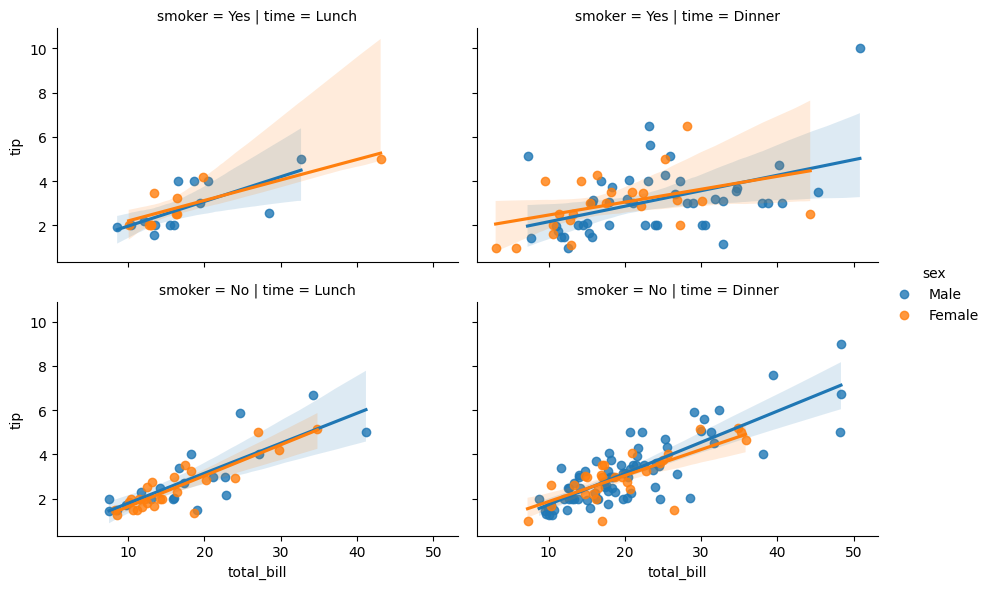

In [7]:
sns.lmplot(
    data=tips,
    x="total_bill", y="tip", hue="sex", col="time", row="smoker",
    aspect=1.5, height=3
)

## Plots for Studies: FMRI

When you want to **examine effects across many levels of a variable**, it can be a good idea to facet that variable on the columns and then “wrap” the facets into the rows:

In [21]:
fmri = sns.load_dataset("fmri")
fmri.head()

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


In [22]:
fmri['subject'] = fmri['subject'].str.replace(r'^s', '', regex=True).astype(int)
fmri = fmri.sort_values(by=["subject", "timepoint", "event"])
fmri.head()

,subject,timepoint,event,region,signal
932,0,0,cue,frontal,0.007766
1063,0,0,cue,parietal,-0.006899
67,0,0,stim,frontal,-0.021452
521,0,0,stim,parietal,-0.039327
624,0,1,cue,frontal,0.016440


In [25]:
cond1 = fmri['subject'].isin([0, 1, 2, 3, 4])
cond2 = fmri['region'] == 'frontal'

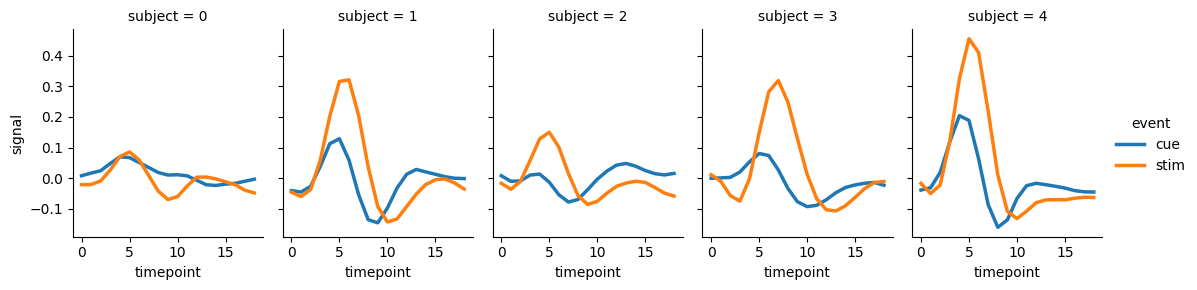

In [27]:
sns.relplot(
    data=fmri[cond1 & cond2], kind="line",
    
    x="timepoint", # Numerical
    y="signal",    # Numerical
    hue="event",   # Categorical
    col="subject", # Categorical
    
    height=3, aspect=.75, linewidth=2.5,
)